**1. 데이터 파악하기**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

!git clone https://github.com/taehojo/data.git

df = pd.read_csv("./data/house_train.csv")

df

fatal: destination path 'data' already exists and is not an empty directory.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


**2. 결측치, 카테고리 변수 처리하기**

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
#카테고리형 변수를 0과 1로 이루어진 변수로 변환
df = pd.get_dummies(df)

#결측치를 전체 칼럼의 평균으로 대체
df = df.fillna(df.mean())

#업데이트된 데이터 출력
df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


**3. 속성별 관련도 추출하기**

In [ ]:
#데이터 사이의 상관 관계 저장
df_corr = df.corr()

#집 값과 관련이 큰 것부터 순서대로 저장
df_corr_sort = df_corr.sort_values('SalePrice', ascending=False)

#집 값과 관련도가 높은 10개의 속성 출력
df_corr_sort['SalePrice'].head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
BsmtQual_Ex,0.553105
TotRmsAbvGrd,0.533723


<function matplotlib.pyplot.show(close=None, block=None)>

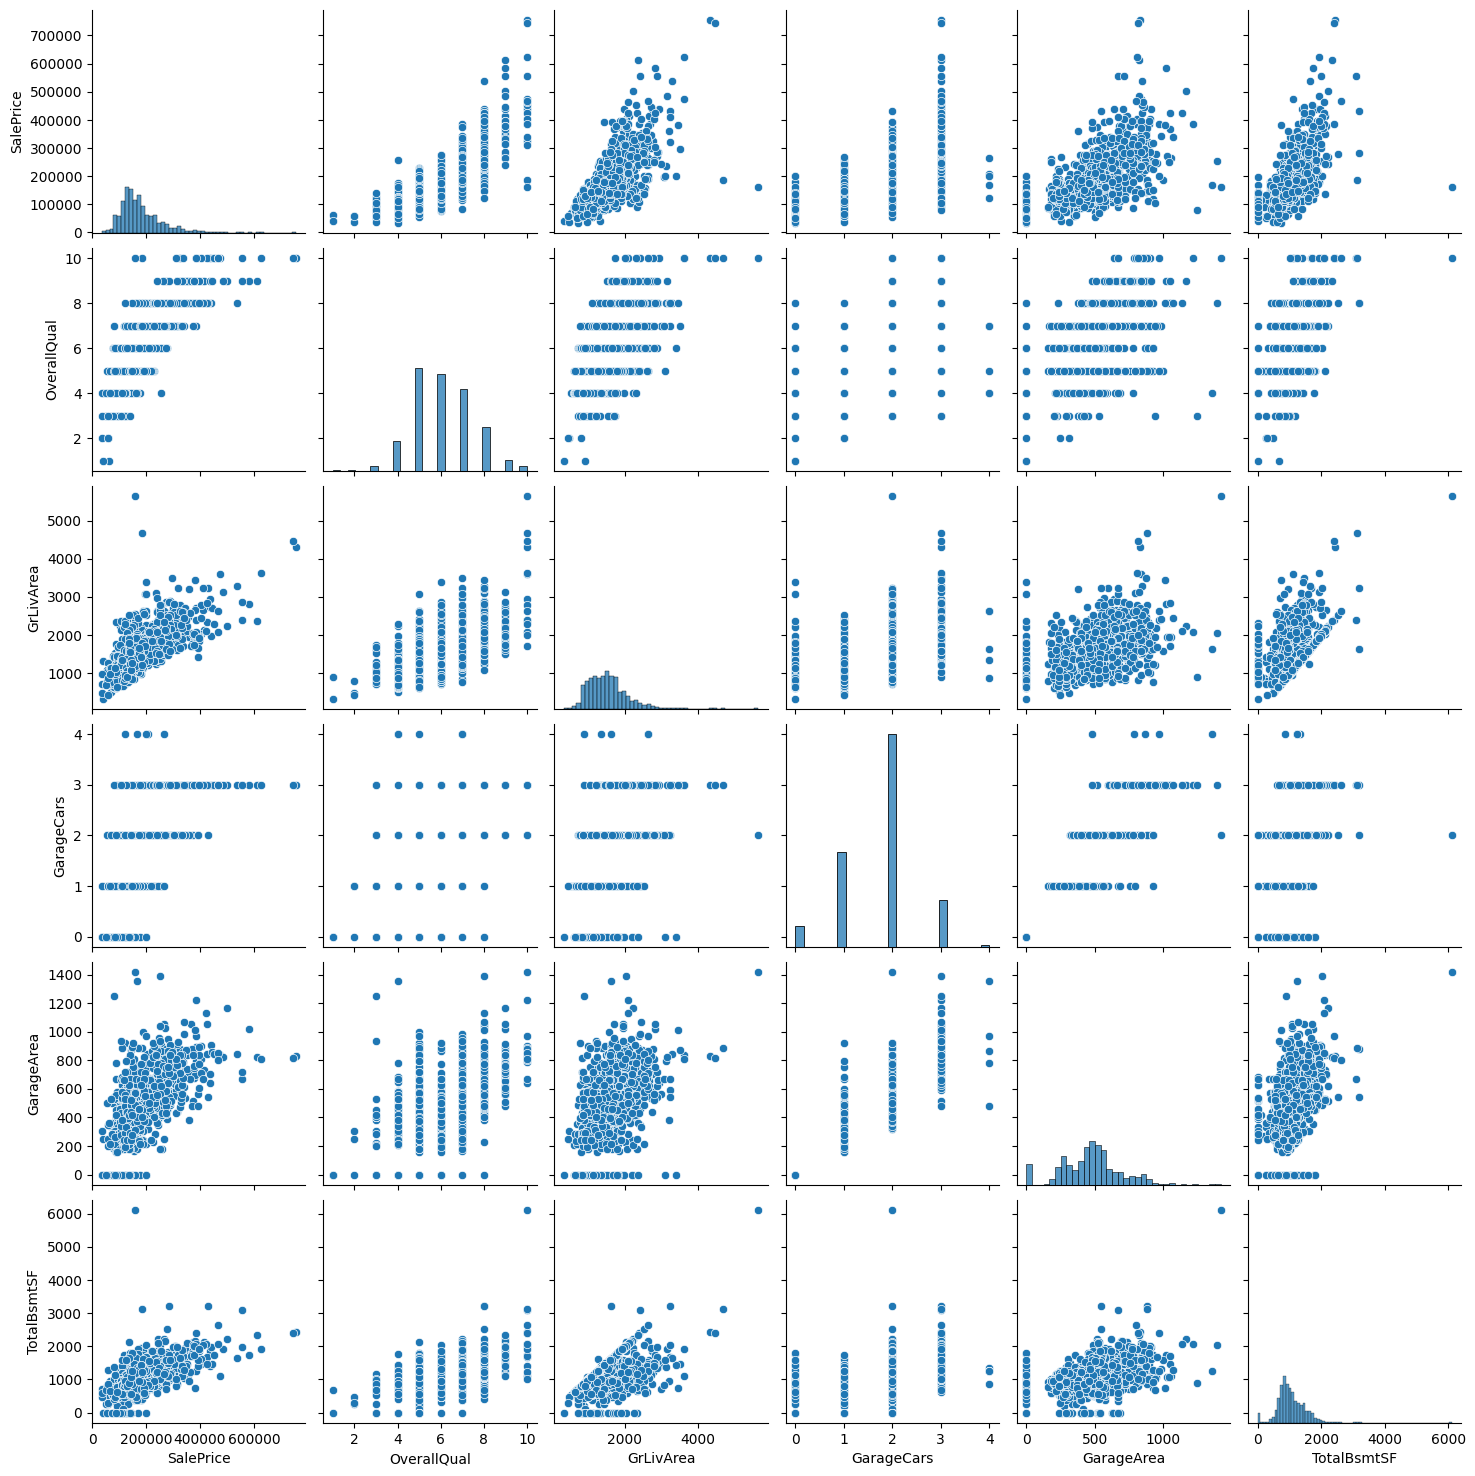

In [ ]:
#집 값과 관련도가 높은 속성들을 추출해 상관도 그래프 작성

cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']
sns.pairplot(df[cols])
plt.show

**4. 주택 가격 예측 모델**

In [ ]:
#집 값을 제외한 나머지 열 저장
cols_train = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']
X_train_pre = df[cols_train]

#집 값 저장
y = df['SalePrice'].values

X_train, X_test, y_train, y_test = train_test_split(X_train_pre, y, test_size=0.2)

#모델 구조 설정
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1))
model.summary()

#모델 실행
model.compile(optimizer='adam', loss='mean_squared_error')

#20회 이상 결과 향상이 없을 시 자동 중단
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

#모델 이름 설정
modelpath = "./data/model/Ch15-house.keras"

#최적화 모델 업데이트&저장
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=0, save_best_only=True)

#전체의 20%를 검증셋으로 설정
history = model.fit(X_train, y_train, validation_split=0.25, epochs=2000, batch_size=32, callbacks=[early_stopping_callback, checkpointer])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,671 (6.53 KB)

 Trainable params: 1,671 (6.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 39087132672.0000 - val_loss: 40265355264.0000
Epoch 2/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 38724870144.0000 - val_loss: 39712366592.0000
Epoch 3/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37833764864.0000 - val_loss: 38258757632.0000
Epoch 4/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35641294848.0000 - val_loss: 34863333376.0000
Epoch 5/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30900154368.0000 - val_loss: 28137861120.0000
Epoch 6/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22624321536.0000 - val_loss: 17710383104.0000
Epoch 7/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11967668224.0000 - val_loss: 7273782272.0000
Epoch 8/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4311700992.0000 - val_loss: 2517942272.0000
Epoch 9/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2280042496.0000 - val_loss: 2076091392.0000
Epoch 10/2000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

In [ ]:
#예측 값과 실제 값, 실행 번호가 들어갈 빈 리스트 생성
real_prices =[]
pred_prices = []
X_num = []

# 25개의 샘플을 뽑아 실제 값, 예측 값을 출력
n_iter = 0
Y_prediction = model.predict(X_test).flatten()
for i in range(25):
    real = y_test[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.2f}, 예상가격: {:.2f}".format(real, prediction))
    real_prices.append(real)
    pred_prices.append(prediction)
    n_iter = n_iter + 1
    X_num.append(n_iter)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
실제가격: 140000.00, 예상가격: 175000.28
실제가격: 154000.00, 예상가격: 137454.39
실제가격: 160000.00, 예상가격: 238018.81
실제가격: 140000.00, 예상가격: 188221.11
실제가격: 175000.00, 예상가격: 157666.92
실제가격: 325000.00, 예상가격: 265508.19
실제가격: 149000.00, 예상가격: 151409.81
실제가격: 124000.00, 예상가격: 156107.55
실제가격: 155900.00, 예상가격: 128123.59
실제가격: 135000.00, 예상가격: 223875.38
실제가격: 120500.00, 예상가격: 126685.77
실제가격: 224500.00, 예상가격: 203782.86
실제가격: 176000.00, 예상가격: 200535.59
실제가격: 359100.00, 예상가격: 270015.91
실제가격: 142000.00, 예상가격: 124871.37
실제가격: 611657.00, 예상가격: 329587.34
실제가격: 197900.00, 예상가격: 226061.28
실제가격: 120000.00, 예상가격: 130256.16
실제가격: 119000.00, 예상가격: 213496.30
실제가격: 188700.00, 예상가격: 154409.83
실제가격: 195000.00, 예상가격: 186095.81
실제가격: 126175.00, 예상가격: 141702.86
실제가격: 150000.00, 예상가격: 204007.02
실제가격: 177500.00, 예상가격: 180163.17
실제가격: 117000.00, 예상가격: 206217.48


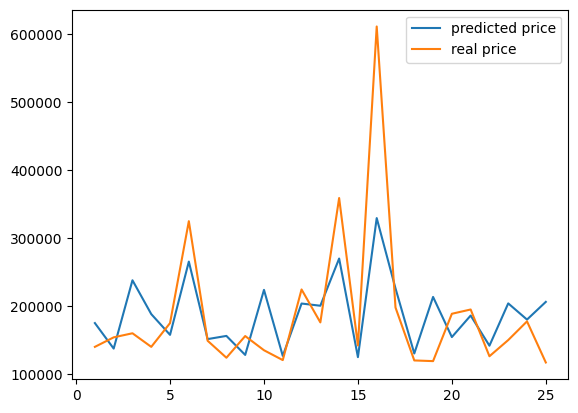

In [ ]:
#그래프를 통해 샘플로 뽑은 25개의 값 비교

plt.plot(X_num, pred_prices, label='predicted price')
plt.plot(X_num, real_prices, label='real price')
plt.legend()
plt.show()